In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

##
TEMPORAL DYNAMICS OF CHANGE

In this notebook, we examine the temporal dynamics of sensor data from the MmCows dataset in order to understand patterns of change in the system. Following Butner (2018), we focus on understanding how behavior unfolds over time by identifying the temporal signature of the data and see whether the observed patterns reflect meaningful structure or random variability.

Specifically, this analysis investigates these properties of temporal dynamics:
1.	Temporal signature – what patterns emerge over time in the system’s behavior? 
2.	Order of change – does the system exhibit first-order (trends), second-order (oscillations), or more complex dynamics? 
3.	Variability – can observed fluctuations be attributed to measurement error, random processes, or meaningful system dynamics? 
4.	Stationarity – do the statistical properties of the system remain stable over time?

To address these questions, we combine visualization and statistical testing. We assess the temporal structure by introducing noise and comparing the data to a random walk process, allowing us to distinguish structured behavior from randomness.
The MmCows dataset contains time series sensor data collected from wearable devices attached to dairy cows. In this notebook, we focus on ankle acceleration as an indicator of movement behavior.


The chosen subset of data consists of 19,831 observations of ankle acceleration recorded from a single dairy cow. Acceleration is measured along three axes (x, y, z), providing a continuous time series of movement.
The data is sampled at regular time intervals of  one minute, this analysis focuses on the x-axis acceleration as a representative time series. this approach allows for a clear and focused examination of temporal dynamics, while remaining representative of the system as a whole.


In [2]:
df = pd.read_csv("C01.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19831 entries, 0 to 19830
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  19831 non-null  int64  
 1   accel_x    19831 non-null  float64
 2   accel_y    19831 non-null  float64
 3   accel_z    19831 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 619.8 KB


The dataset provides timestamps as integer values, which represent time in seconds since the Unix epoch. To make the data interpretable and suitable for analysis, these timestamps are converted into a standard datetime format. This allows the time series to be properly ordered and visualized over real-world time.

The converted time variable below shows a consistent one-minute sampling interval, confirming that the data is regularly sampled and suitable for temporal analysis.

In [3]:
df["time"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")

In [4]:
df[["timestamp", "time"]].head()

,timestamp,time
0,1689960600,2023-07-21 17:30:00
1,1689960660,2023-07-21 17:31:00
2,1689960720,2023-07-21 17:32:00
3,1689960780,2023-07-21 17:33:00
4,1689960840,2023-07-21 17:34:00


##
TEMPORAL SIGNATURE INTERPRETATION

To begin, we visualized the the time series to examine its temporal signature. 


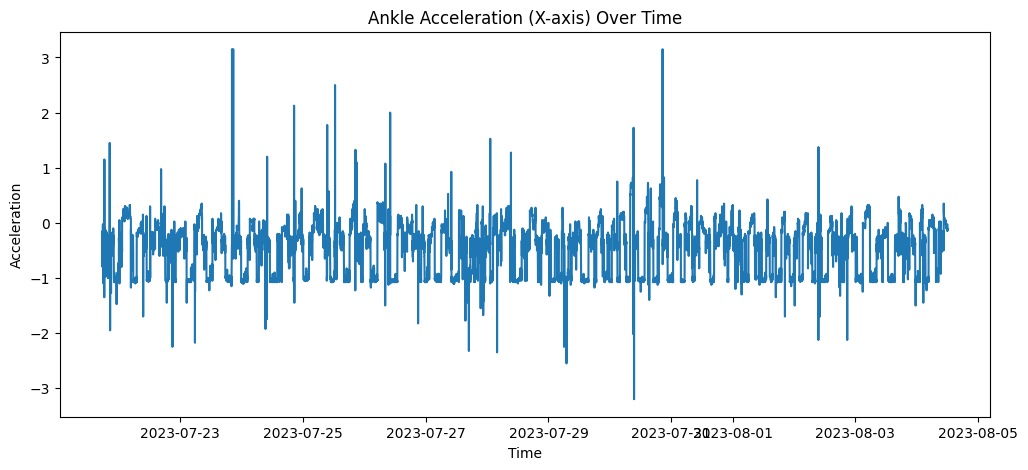

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df["time"], df["accel_x"])
plt.title("Ankle Acceleration (X-axis) Over Time")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.show()


The time series shows irregular fluctuations centered around zero, with lots of rapid changes and occasional large spikes. 



##
ORDERS OF CHANGE

Different types of temporal dynamics can be categorized by their order of change. First-order change involves linear, constant and non-constant changing values , second-order change involves oscillatory behavior, and third-order of change is characterized by irregular and complex patterns.
The observed data is closest to a combination second order characteristics, where the oscillations around zero are much like constant oscillation (blue curve), with some spikes reflecting oscillating frequency. There is no clear linear trend nor is there chaotically behaving patterns like first and third orders of change.


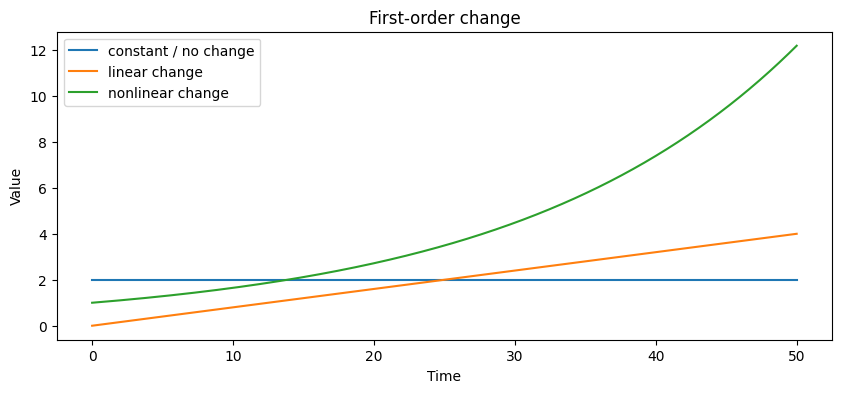

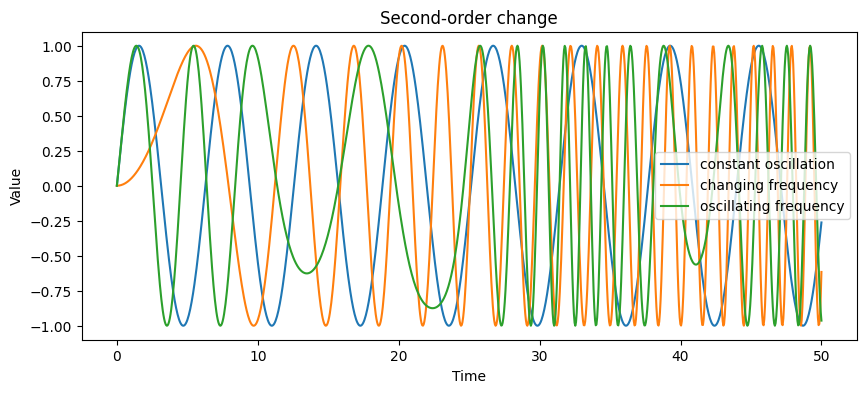

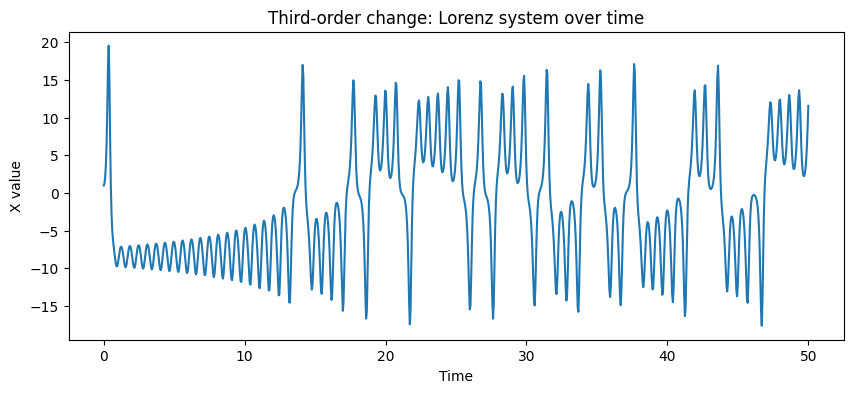

In [6]:
t = np.linspace(0, 50, 1000)

# 1) FIRST-ORDER CHANGE
constant = np.ones_like(t) * 2
linear = 0.08 * t
nonlinear = np.exp(0.05 * t)

plt.figure(figsize=(10, 4))
plt.plot(t, constant, label="constant / no change")
plt.plot(t, linear, label="linear change")
plt.plot(t, nonlinear, label="nonlinear change")
plt.title("First-order change")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


# 2) SECOND-ORDER CHANGE
constant_oscillation = np.sin(t)

changing_frequency = np.sin(0.05 * t**2)

oscillating_frequency = np.sin(t * (1 + 0.5 * np.sin(0.2 * t)))

plt.figure(figsize=(10, 4))
plt.plot(t, constant_oscillation, label="constant oscillation")
plt.plot(t, changing_frequency, label="changing frequency")
plt.plot(t, oscillating_frequency, label="oscillating frequency")
plt.title("Second-order change")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


# 3) THIRD-ORDER CHANGE
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

solution = solve_ivp(
    lorenz,
    t_span=(0, 50),
    y0=[1, 1, 1],
    t_eval=t,
    max_step=0.01
)

x, y, z = solution.y

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.title("Third-order change: Lorenz system over time")
plt.xlabel("Time")
plt.ylabel("X value")
plt.show()



##
VARIABILITY AND MEASUREMENT ERROR 

In real-world data, variability can arise from both meaningful system dynamics and measurement error. To assess the robustness of the observed temporal signature, we added artificial noise to the time series.

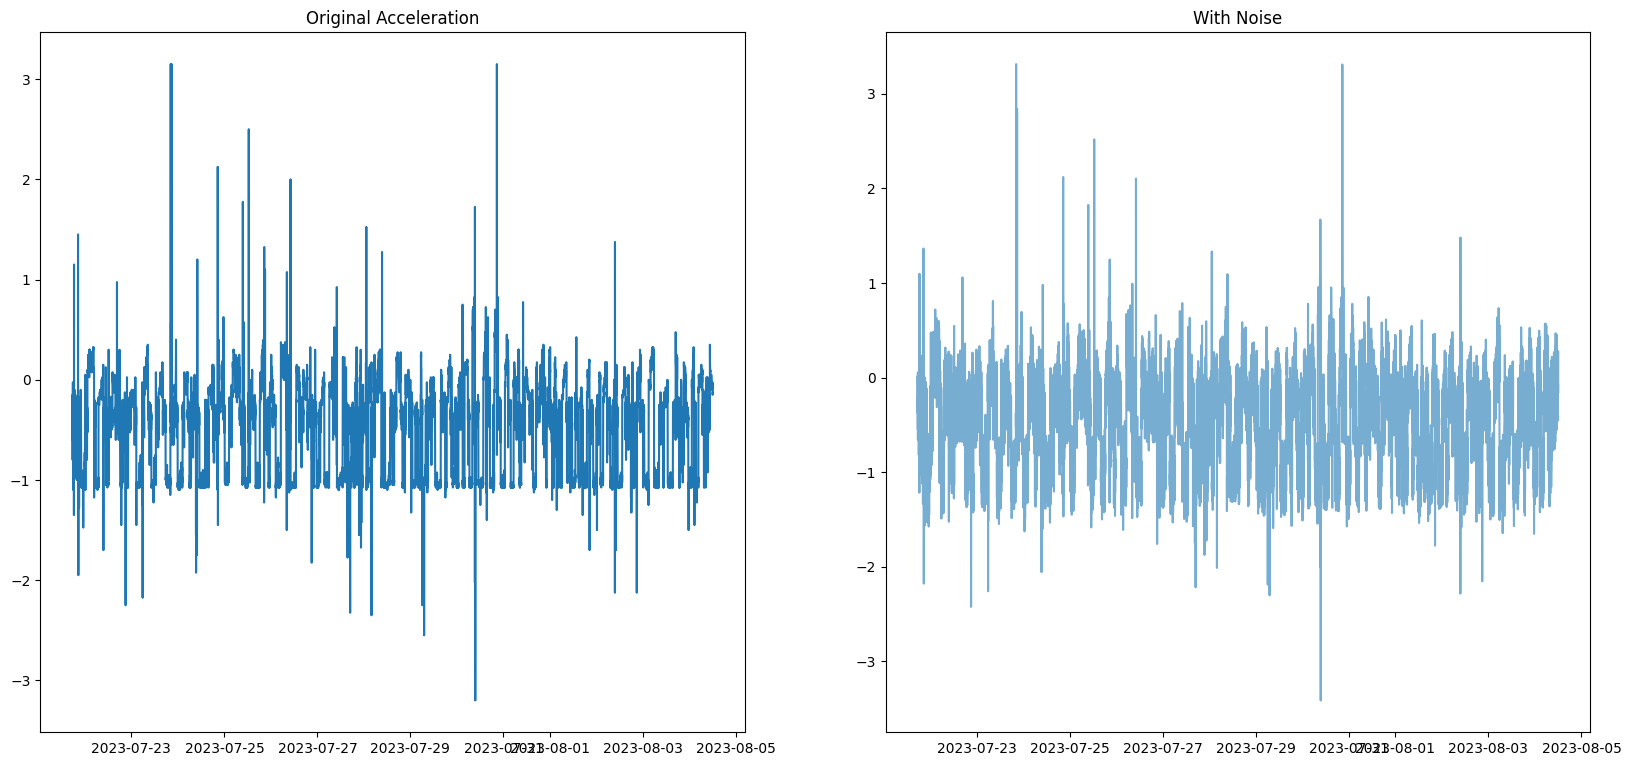

In [30]:
noise = np.random.normal(0, df["accel_x"].std()*0.4, size=len(df))
df["accel_noise"] = df["accel_x"] + noise

plt.figure(figsize=(20,20))
plt.subplot(2,2,1)  
plt.plot(df["time"], df["accel_x"]), plt.title("Original Acceleration")
plt.subplot(2,2,2)
plt.plot(df["time"], df["accel_noise"], alpha=0.6), plt.title("With Noise")
plt.show()

The comparison shows that adding noise increases the spread of the signal and makes the time series appear more visually dispersed. The overall structure of the original signal is still recognizable. Both plots show fluctuations around a similar baseline, and several of the larger spikes remain visible after noise is added.

This suggests that the temporal signature is not simply the result of random measurement error. Although noise makes the signal less clean, it does not fully obscure the underlying pattern. Therefore, the variability in the cow’s ankle acceleration likely reflects a combination of sensor noise and meaningful behavioral changes.

According to Butner (2018), a random walk reflects a process in which changes accumulate over time without a stabilizing force, leading to drift away from an initial value. In such systems, the “real value of change” does not remain stable, but instead evolves as a result of cumulative randomness.

To show this, a simulated random walk was generated. Unlike the ankle acceleration data, which fluctuates around a relatively stable baseline, the random walk shows clear drift over time and does not return to a central level. This highlights a key distinction: while both signals contain variability, the random walk reflects unbounded stochastic change and the cow ankle data appears constrained and centered.

This suggests that the variability observed in the cow’s movement is not consistent with a pure random walk process, but instead reflects structure.

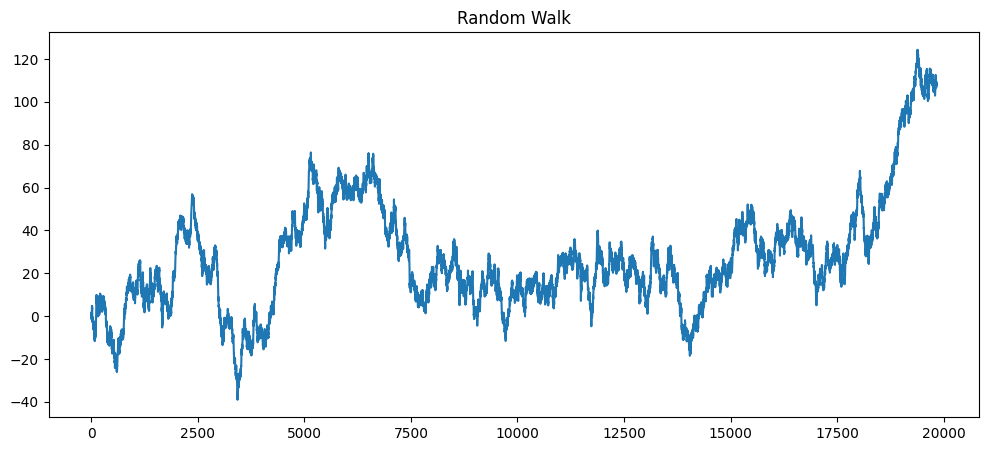

In [13]:
rw = np.cumsum(np.random.normal(0, 1, len(df)))

plt.figure(figsize=(12,5))
plt.plot(rw)
plt.title("Random Walk")
plt.show()

##
STATIONARITY

Stationarity refers to whether the statistical properties of a time series like as its mean, variance, and autocorrelation structure remain constant over time. A stationary process fluctuates around a stable baseline and does not exhibit systematic trends or changing variability. Assessing stationarity is important because many time-series models assume that the underlying process is stable rather than evolving over time.

STATIONARITY TESTS

Two complementary statistical tests were used to assess stationarity: the Augmented Dickey-Fuller (ADF) test and the KPSS test.

Augmented Dickey-Fuller (ADF) test
The ADF test evaluates the null hypothesis that the time series is non-stationary, specifically that it contains a unit root (i.e., it follows a stochastic trend such as a random walk).
- Null hypothesis: the series is non-stationary
- Alternative hypothesis: the series is stationary
A small p-value indicates evidence against non-stationarity.

KPSS (Kwiatkowski-Phillips-Schmidt-Shin) test
The KPSS test takes the opposite approach by evaluating the null hypothesis that the time series is stationary around a constant mean (or trend, depending on specification).
- Null hypothesis: the series is stationary
- Alternative hypothesis: the series is non-stationary. 
A large p-value indicates that stationarity cannot be rejected.

Using both tests together provides a more robust assessment, as they test opposing hypotheses.

In [5]:

# ADF test (null = non-stationary)
adf_result = adfuller(df["accel_x"])
print("ADF p-value:", adf_result[1])

# KPSS test (null = stationary)
kpss_result = kpss(df["accel_x"], regression='c')
print("KPSS p-value:", kpss_result[1])

ADF p-value: 1.2931503801932922e-24
KPSS p-value: 0.1


The Augmented Dickey-Fuller (ADF) test shows a very small p-value, allowing rejection of the null hypothesis of non-stationarity. This suggests that the time series does not exhibit a unit root or stochastic trend.

The KPSS test produced a high p-value, indicating that the null hypothesis of stationarity could not be rejected. This suggests that the series is consistent with a stable mean over time.

Together, these results provide  evidence that the time series is stationary which implies that the system fluctuates around a stable baseline, rather than undergoing systematic change, which is consistent with the observed temporal signature.

##
CONCLUSION



The ankle acceleration data shows that the signal oscillates around zero with some spikes which is consistent with second-order dynamics. Adding noise didn't meaningfully change this, and the random walk comparison made the difference clear. 

The stationarity tests backed this up. Both the ADF and KPSS pointed in the same direction and  are consistent with what the visualizations already suggested.

What this means practically is that the cow's movement over this two-week period follows a somewhat stable process. The occasional spikes are real, but they're interruptions rather than signs of a shifting system. 